Understanding Image as a Matrix

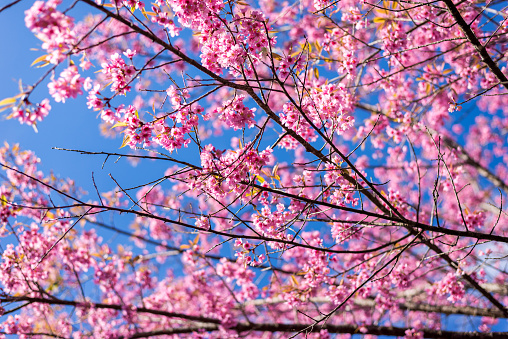

In [ ]:
from PIL import Image
#display image in colab
image_colored = Image.open("/content/istockphoto-543346580-170667a.jpg")
display(image_colored)

Getting Image Properties

In [ ]:
print ( " Image Format : " , image_colored . format )
print ( " Image Size : " , image_colored . size )
print ( " Image Mode : " , image_colored . mode )

 Image Format :  JPEG
 Image Size :  (508, 339)
 Image Mode :  RGB


Getting Shape and Size of an Image Using PIL

In [ ]:
# Get the size (width , height ) and channels (RGB)
width , height = image_colored . size
channels = len( image_colored . getbands () ) # For RGB , it will be 3
print ( f" Image shape (RGB): ({ height } , { width } , { channels})")
image_size_colored = width * height *3
print ( f" Image size (RGB): { image_size_colored }")

 Image shape (RGB): (339 , 508 , 3)
 Image size (RGB): 516636


Converting Image to NumPy Array.

In [ ]:
import numpy as np
# Convert the Pillow image to a NumPy array
image_array_colored = np . array ( image_colored )
# Display the shape of the NumPy array (height , width ,channels)
print (" Shape of the image array :", image_array_colored .shape )

 Shape of the image array : (339, 508, 3)


Extracting Colored Channels with NumPy Array.

 Shape of the image array : (339, 508, 3)
[[107 104 100 ...  47  50  65]
 [106 106 106 ...  38  48  79]
 [106 105 105 ...  20  29  80]
 ...
 [228 251 255 ...  17  14  14]
 [232 254 255 ...  20  16  15]
 [204 231 239 ...  22  18  17]]


array([[107, 104, 100, ...,  47,  50,  65],
       [106, 106, 106, ...,  38,  48,  79],
       [106, 105, 105, ...,  20,  29,  80],
       ...,
       [228, 251, 255, ...,  17,  14,  14],
       [232, 254, 255, ...,  20,  16,  15],
       [204, 231, 239, ...,  22,  18,  17]], dtype=uint8)
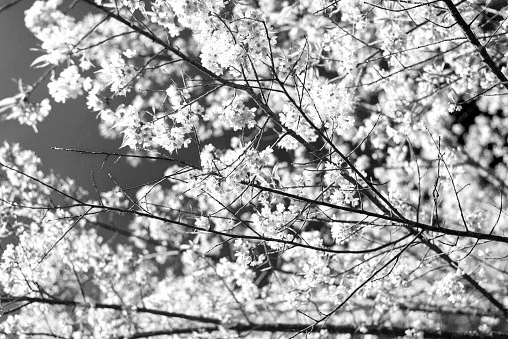

[[154 154 154 ...  51  58  60]
 [154 152 152 ...  87  95  89]
 [154 153 155 ... 112 109 115]
 ...
 [190 195 205 ...   2   2   2]
 [149 188 202 ...   5   4   3]
 [ 71 119 128 ...   7   6   5]]


array([[154, 154, 154, ...,  51,  58,  60],
       [154, 152, 152, ...,  87,  95,  89],
       [154, 153, 155, ..., 112, 109, 115],
       ...,
       [190, 195, 205, ...,   2,   2,   2],
       [149, 188, 202, ...,   5,   4,   3],
       [ 71, 119, 128, ...,   7,   6,   5]], dtype=uint8)
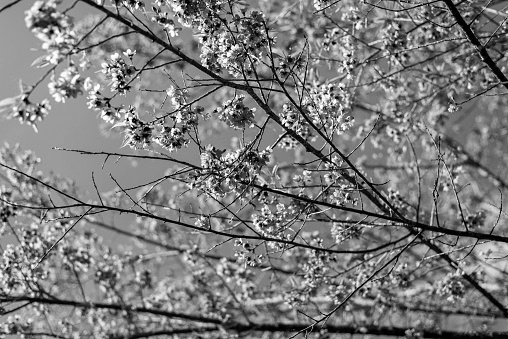

In [ ]:
# Convert the Pillow image to a NumPy array
image_array_colored = np . array ( image_colored )
# Display the shape of the NumPy array (height , width ,channels )
print (" Shape of the image array :", image_array_colored . shape)
#For Red Channels
red_channel = image_array_colored [: , : , 0] # Red channel
print ( red_channel )
display ( red_channel )
# For Green Channels
green_channel = image_array_colored [: , : , 1] # Greenchannel
print ( green_channel )
display ( green_channel )

[[226 227 226 ...  98 105 116]
 [230 230 230 ... 180 187 174]
 [226 225 226 ... 199 206 196]
 ...
 [213 230 236 ...   5   4   4]
 [175 215 229 ...   8   6   5]
 [116 165 181 ...  10   8   7]]


array([[226, 227, 226, ...,  98, 105, 116],
       [230, 230, 230, ..., 180, 187, 174],
       [226, 225, 226, ..., 199, 206, 196],
       ...,
       [213, 230, 236, ...,   5,   4,   4],
       [175, 215, 229, ...,   8,   6,   5],
       [116, 165, 181, ...,  10,   8,   7]], dtype=uint8)
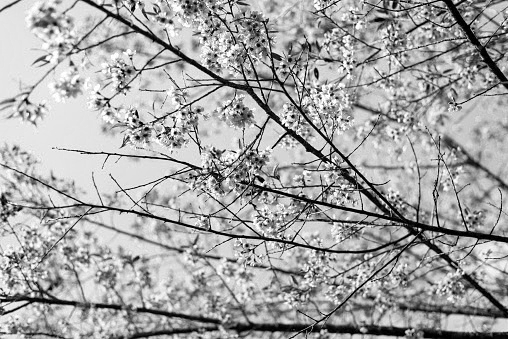

In [ ]:
# For Blue Channel :
blue_channel = image_array_colored [: , : , 2] # Blue channel
print ( blue_channel )
display ( blue_channel )

Extracting Sub Images(cropping) Using PIL

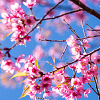

In [ ]:
# Define the cropping box (left , upper , right , lower )
left, upper, right, lower = 100, 50, 200, 150
# Crop the image
cropped_image = image_colored . crop (( left , upper , right ,lower ) )
# Display the cropped image
display ( cropped_image )

Saving NumPy Array to Image.

In [ ]:
# Create a NumPy array (Here , we use a dummy array for illustration )
image_array = np . zeros ((100 , 100 , 3) , dtype = np . uint8 ) #Example : black image
# Convert the NumPy array back to a Pillow Image object
image_from_array = Image . fromarray ( image_array )
# Display the image
image_from_array . show ()
# Optionally save the image to a file
image_from_array . save ("output_image.jpg")

3.Understanding PCA for Image Compression.” With Eigen Value Decomposition.”

Load and Prepare Image Data


In [ ]:
import numpy as np
import matplotlib . pyplot as plt
from PIL import Image
# Load image and convert to grayscale
image = Image . open ("/content/istockphoto-543346580-170667a.jpg") . convert ("L")
# Convert to NumPy array
image_array = np . array ( image )
# Get image dimensions
height , width = image_array . shape
# Reshape the image into a 2D array where each row represents a row of pixels
# This allows PCA to process each row as an observation and find patterns across pixel intensities
data = image_array . reshape ( height , width )

Standarize the Data

In [ ]:
# Compute the mean of each column ( feature )
mean = np . mean ( data , axis =0)
# Subtract mean to center the data
centered_data = data - mean

Compute Covariance Matrix:

In [ ]:
# Compute covariance matrix
cov_matrix = np . cov ( centered_data , rowvar = False )

Compute Eigenvalues & Eigenvectors:

In [ ]:
# Compute eigenvalues and eigenvectors
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
# Sort eigenvalues and corresponding eigenvectors indescending order
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]

Explained Variance:

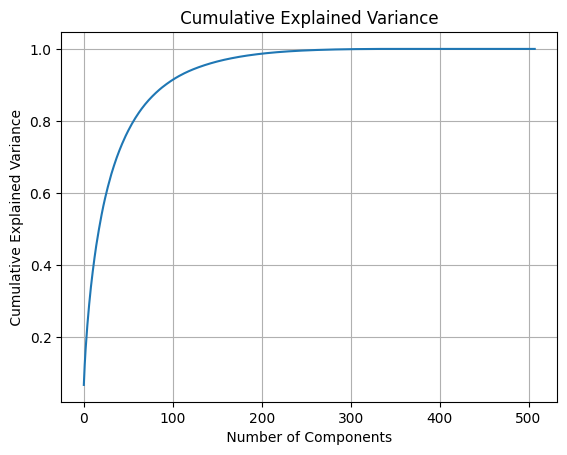

In [ ]:
# Plot the explained variance ratio
explained_variance_ratio = eigenvalues / np .sum ( eigenvalues )
plt . plot ( np . cumsum ( explained_variance_ratio ) )
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()

Select Top k Principal Component

In [ ]:
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]

Compress the Image

In [ ]:
# Project the data onto the principal components
compressed_data = np.dot(centered_data, components)

Reconstruct (Decompress) the Image

In [ ]:
# Reconstruct the image from compressed data
decompressed_data = np . dot ( compressed_data , components . T ) + mean

Final Visualizaion

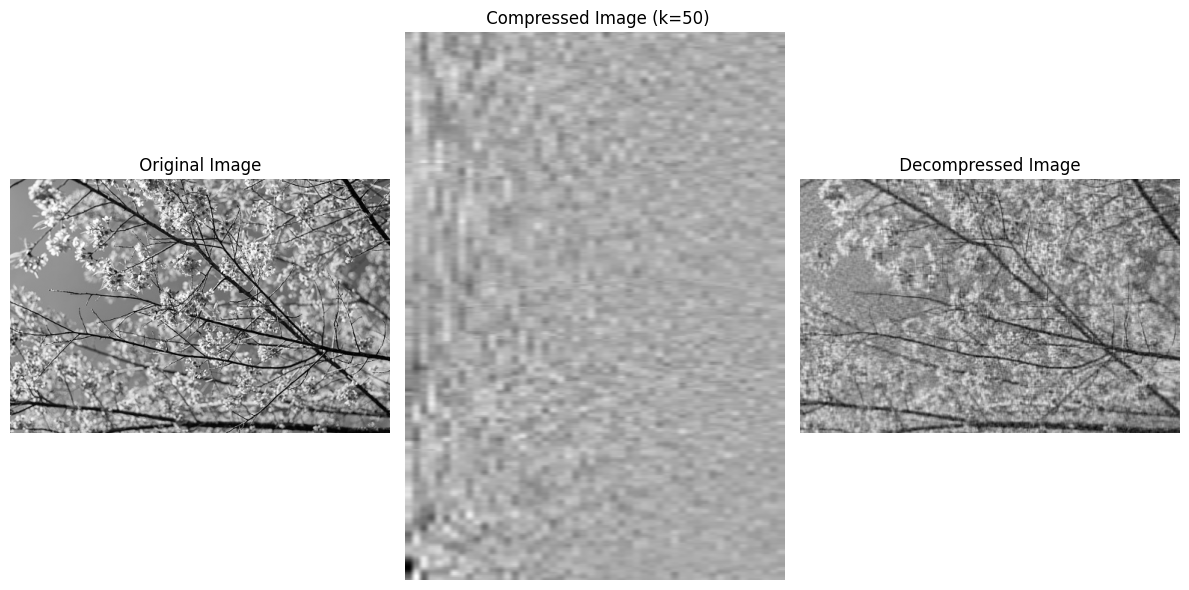

In [ ]:
plt . figure ( figsize =(12 , 6) )
# Original Image
plt . subplot (1 , 3 , 1)
plt . imshow ( image_array , cmap ="gray")
plt . title (" Original Image ")
plt . axis ("off")
# Compressed Representation
plt . subplot (1 , 3 , 2)
plt . imshow ( compressed_data , cmap ="gray", aspect ="auto")
plt . title ( f" Compressed Image (k={k})")
plt . axis ("off")
# Decompressed Image
plt . subplot (1 , 3 , 3)
plt . imshow ( decompressed_data , cmap ="gray")
plt . title (" Decompressed Image ")
plt . axis ("off")
plt . tight_layout ()
plt . show ()